In [61]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from Bio import Phylo
import argparse


def custom_label1(clade):
    if clade.is_terminal():
        return clade.name
    else:
        return None
def custom_label(clade):
    # Check if the clade is terminal (taxa labels)
    if clade.is_terminal():
        return clade.name  # Replace with None to suppress taxa labels
    else:
        return None  # Suppress branch lengths or internal node labels


def custom_label2(clade):
    if clade.is_terminal() and clade.name:
        # Example: Split the label into ID and species name
        parts = clade.name.split(" ", 1)  # Assumes "ID SpeciesName" format
        if len(parts) == 2:
            node_id, species_name = parts
            # Use matplotlib's native formatting for italic text
            return f"{node_id} {species_name}"
        else:
            # If no species name, return the full label
            return clade.name
    else:
        return None


def calc_node_positions(tree, x_start, x_end, y_start, y_step):
    if tree.is_terminal():
        x_pos = x_start
        y_pos = y_start
        y_start += y_step
    else:
        x_pos = (x_start + x_end) / 2
        y_pos = y_start

        child_y_start = y_start
        for child in tree.clades:
            child_x_pos, child_y_pos, y_start = calc_node_positions(
                child, x_start, x_end, y_start, y_step
            )
            x_start = child_x_pos

        y_pos = (y_start + child_y_start) / 2

    tree.position = (x_pos, y_pos)
    return x_pos, y_pos, y_start


def get_x_offset(node_name, offsets_dict):
    return offsets_dict.get(node_name, 0)  # default offset is 0 if not found


def plot_adjusted_node(ax, node, y_offset, offsets_dict, gps):
    x, y = node.position
    x_offset = get_x_offset(node.name, offsets_dict)
    x += x_offset
    y += y_offset

    # Default color if node name is not found
    color = "grey"

    # Check if node name is in the gps DataFrame and set color accordingly
    if node.name in gps["specimen_id"].values:
        color = gps[gps["specimen_id"] == node.name]["color"].values[0]

    ax.plot(
        x,
        y,
        "o",
        markersize=8,
        markerfacecolor=color,
        markeredgewidth=2,
        markeredgecolor="black",
    )
    return x, y


def value_to_color_old(val):
    if val == 0.00:
        return "black"
    elif 0.00 < val < 0.7:
        # Gradient from orange to yellow
        cmap = plt.get_cmap("viridis")  # Yellow to red colormap
        norm = mcolors.Normalize(vmin=0.02, vmax=0.06)
        return mcolors.to_hex(cmap(norm(val)))
    elif val == 0.7:
        return "green"
    else:
        return "grey"


def value_to_color(val):
    color_map = {
        1: "red",
        2: "blue",
        3: "green",
        4: "purple",
        5: "orange",
        6: "cyan",
        7: "magenta",
        8: "grey",
        9: "brown",
    }
    return color_map.get(
        val, "black"
    )  # Default to 'grey' if the value is not in the dictionary


# Create a new map with PlateCarree projection
fig = plt.figure(figsize=(26, 11))

# --------------------------------------
# ------------  Phylogenetic MAP -------
# --------------------------------------
#nwk_file = r"..\data\Final_sequences_aligned_MAFFT_Ubuntu_CIAlign_cleaned_1_tree.nwk"
nwk_file = r"..\data\Final_sequences_aligned_MAFFT_Ubuntu_CIAlign_cleaned_1_tree_tree.nwk"
# Load the tree
tree = Phylo.read(nwk_file, "newick")

# Load offsets from CSV
offset_file = r"..\data\offset_longname.csv"
offsets_df = pd.read_csv(offset_file)
offsets_dict = pd.Series(offsets_df.XOffset.values, index=offsets_df.NodeName).to_dict()

# Calculate positions for all nodes
y_step = 1
calc_node_positions(tree.root, 0, 1, 0, y_step)

# Create a figure for the subplot
ax_tree = fig.add_subplot(121)

gps_file = r"..\data\Updated_Dataset_Tree_ID_3.csv"
gps = pd.read_csv(gps_file)
print(gps.columns)

gps["color"] = gps["caffeine_percent"].apply(value_to_color)
text_colors = dict(zip(gps["specimen_id"], gps["color"]))
print(text_colors)
# Plot the tree
Phylo.draw(
    tree, do_show=False, axes=ax_tree, label_func=custom_label, label_colors=text_colors
)

ax_tree.set_xticks([])  # Remove x-axis ticks
ax_tree.set_yticks([])  # Remove y-axis ticks
ax_tree.set_xticklabels([])  # Remove x-axis labels
ax_tree.set_yticklabels([])  # Remove y-axis labels

ax_tree.set_xlabel("")  # Remove x-axis label (branch lengths)
ax_tree.set_ylabel("")  # Remove y-axis label (usually taxa alignment)

ax_tree.set_title("", fontsize=18)
ax_tree.set_frame_on(False)  # Remove the border/frame
# ax_tree.axis('off')         # Turn off the axes, including ticks and labels

# Set axes limits to verify the data range
ax_tree.set_xlim(-0.02, 0.55)
ax_tree.set_ylim(0, max(node.position[1] for node in tree.get_terminals()) + 2)

node_positions = {clade.name: clade.position for clade in tree.find_clades()}

# Generate DataFrame with node coordinates (commented out as unnecessary here)
rows = []
for clade in tree.find_clades():
    if clade.is_terminal():
        label = clade.name
        x, y = plot_adjusted_node(
            ax_tree, clade, y_step, offsets_dict, gps
        )  # Adjust offsets if necessary
        rows.append([label, (x, y)])

# Create DataFrame with node coordinates (commented out as unnecessary here)
df = pd.DataFrame(rows, columns=["ID", "Coordinates"])

# --------------------------------------
# ------------  GRAPH MAP --------------
# --------------------------------------


# Create subplot 2 with the map plot
ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
extent = [-32, -10, 55, 69]
ax2.set_extent(extent)

# Plot points from GPS dataframe on the map
for index, row in gps.iterrows():
    ax2.plot(
        row["longitude"],
        row["latitude"],
        "o",  # Circle marker
        markersize=8,  # Same size as in ax.plot
        markerfacecolor=row["color"],  # Use the color from the 'color' column
        markeredgewidth=2,  # Same edge width
        markeredgecolor="black",  # Same edge color
    )

# Add coastlines and country borders for context
ax2.coastlines(resolution="10m")
ax2.add_feature(cfeature.LAND)
ax2.add_feature(cfeature.OCEAN)
ax2.add_feature(cfeature.COASTLINE)
ax2.add_feature(cfeature.BORDERS)

ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
# ax2.set_title("Species Coordinates", fontsize=18)
# ax2.legend(["0 %dmb caffeine"], loc='upper right')

# --------------------------------------
# ------------  Line mapping -----------
# --------------------------------------

# Group gps DataFrame by ID and create a dictionary of lists of coordinates
gps_grouped = (
    gps.groupby("specimen_id")[["longitude", "latitude", "color"]]
    .apply(lambda x: list(zip(x["longitude"], x["latitude"], x["color"])))
    .to_dict()
)
# print(gps_grouped)
for index, row in df.iterrows():
    # Get corresponding list of coordinates and color from gps DataFrame
    if row["ID"] in gps_grouped:
        species_coords_list = gps_grouped[row["ID"]]
        # Create connection patches for each coordinate in the list
        for species_coords in species_coords_list:
            longitude, latitude, color = species_coords  # Unpack coordinates and color
            con = ConnectionPatch(
                xyA=row["Coordinates"],
                coordsA="data",
                xyB=(longitude, latitude),
                coordsB="data",
                axesA=ax_tree,
                axesB=ax2,
                color=color,  # Use the corresponding color for each specimen_id
                linewidth=1,
                linestyle="--",
                alpha=0.5,
                zorder=2,
            )
            fig.add_artist(con)

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Define the mapping between colors and labels

color_to_label = {
    "red": "Bassin d'Islande",
    "blue": "Bassin d'Irminger",
    "green": "Détroit du Danemark",
    "purple": "Détroit du Danemark",
    "orange": "Bassin Norvégien",
    "cyan": "Détroit du Danemark",
    "magenta": "Mer de Norvège",
    "grey": "Mer de Norvège",
    "brown": "Bassin d'Irminger" #,
    # "grey": "Pas de données"
}

legend_handles = [
    mlines.Line2D(
        [], [],  # Empty data for the legend
        color=color,  # Set color
        marker="o",  # Use circle marker
        markersize=8,  # Adjust circle size
        markeredgecolor="black",  # Black outline
        linestyle="None",  # No connecting line
        label=label  # Set label
    )
    for color, label in color_to_label.items()
]

# Add the legend to the tree plot
ax2.legend(
    handles=legend_handles,
    #title="Caffeine Levels",  # Legend title
    loc="lower right",  # Position in the bottom-right corner
    fontsize=10,  # Font size for labels
    title_fontsize=12,  # Font size for the title
    frameon=True,  # Optional: Add a border around the legend
    markerscale=1.2,  # Optional: Adjust marker scaling
)

plt.tight_layout()
# output_file = r'..\images\figure2.svg'
# plt.savefig(output_file, format='svg')
output_file = r"..\images\figure_tree2map.png"
plt.savefig(output_file, format="png")

plt.close(fig)

Index(['specimen_id', 'longitude', 'latitude', 'caffeine_percent'], dtype='object')
{'ICE1-Bod001_Cyclaspis_longicaudata': 'red', 'ICE1-Bod003': 'blue', 'ICE1-Bod004_Bathycuma_brevirostre': 'red', 'ICE1-Cer002_Cimmerius_reticulatus': 'blue', 'ICE1-Cer003_Cimmerius_reticulatus': 'blue', 'ICE1-Dia001_Leptostylis_ampullacea': 'green', 'ICE1-Dia004_Leptostylis_ampullacea': 'green', 'ICE1-Dia005_Leptostylis_ampullacea': 'purple', 'ICE1-Dia006_Diastylis_polaris': 'orange', 'ICE1-Dia007_Leptostylis_ampullacea': 'green', 'ICE1-Dia008_Leptostylis_ampullacea': 'purple', 'ICE1-Dia009_Diastylis_polaris': 'orange', 'ICE1-Dia010_Diastylis_polaris': 'cyan', 'ICE1-Dia011_Diastyloides_atlanticus': 'red', 'ICE1-Dia012': 'red', 'ICE1-Dia013_Leptostylis_ampullacea': 'cyan', 'ICE1-Dia014_Leptostylis_ampullacea': 'magenta', 'ICE1-Dia016_Diastylis_polaris': 'cyan', 'ICE1-Dia017_Leptostylis_borealis': 'grey', 'ICE1-Dia018_Leptostylis_ampullacea': 'green', 'ICE1-Dia019_Diastylis_polaris': 'magenta', 'ICE1-Dia0

In [49]:
import sys
from Bio import SeqIO, AlignIO, Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
import matplotlib.pyplot as plt
import os


def custom_label(clade):
    if clade.is_terminal():
        return clade.name
    else:
        return None  # Return None for non-terminal nodes


def build_tree(fasta_file):
    # Step 1: Parse sequences from the FASTA file
    alignment = AlignIO.read(fasta_file, "fasta")

    # Step 2: Calculate distance matrix
    calculator = DistanceCalculator("identity")
    distance_matrix = calculator.get_distance(alignment)

    # Step 3: Build phylogenetic tree
    constructor = DistanceTreeConstructor()
    tree = constructor.nj(distance_matrix)

    base_name, extension = os.path.splitext(fasta_file)
    output_tree_file = base_name + "_tree.nwk"

    # Step 4: Save tree to Newick file
    Phylo.write(tree, output_tree_file, "newick")

    # Step 5: Visualize the tree
    fig, ax = plt.subplots(figsize=(20, 10))

    # Draw the tree
    Phylo.draw(tree, axes=ax, label_func=custom_label)

    # Show the plot
    # plt.show()

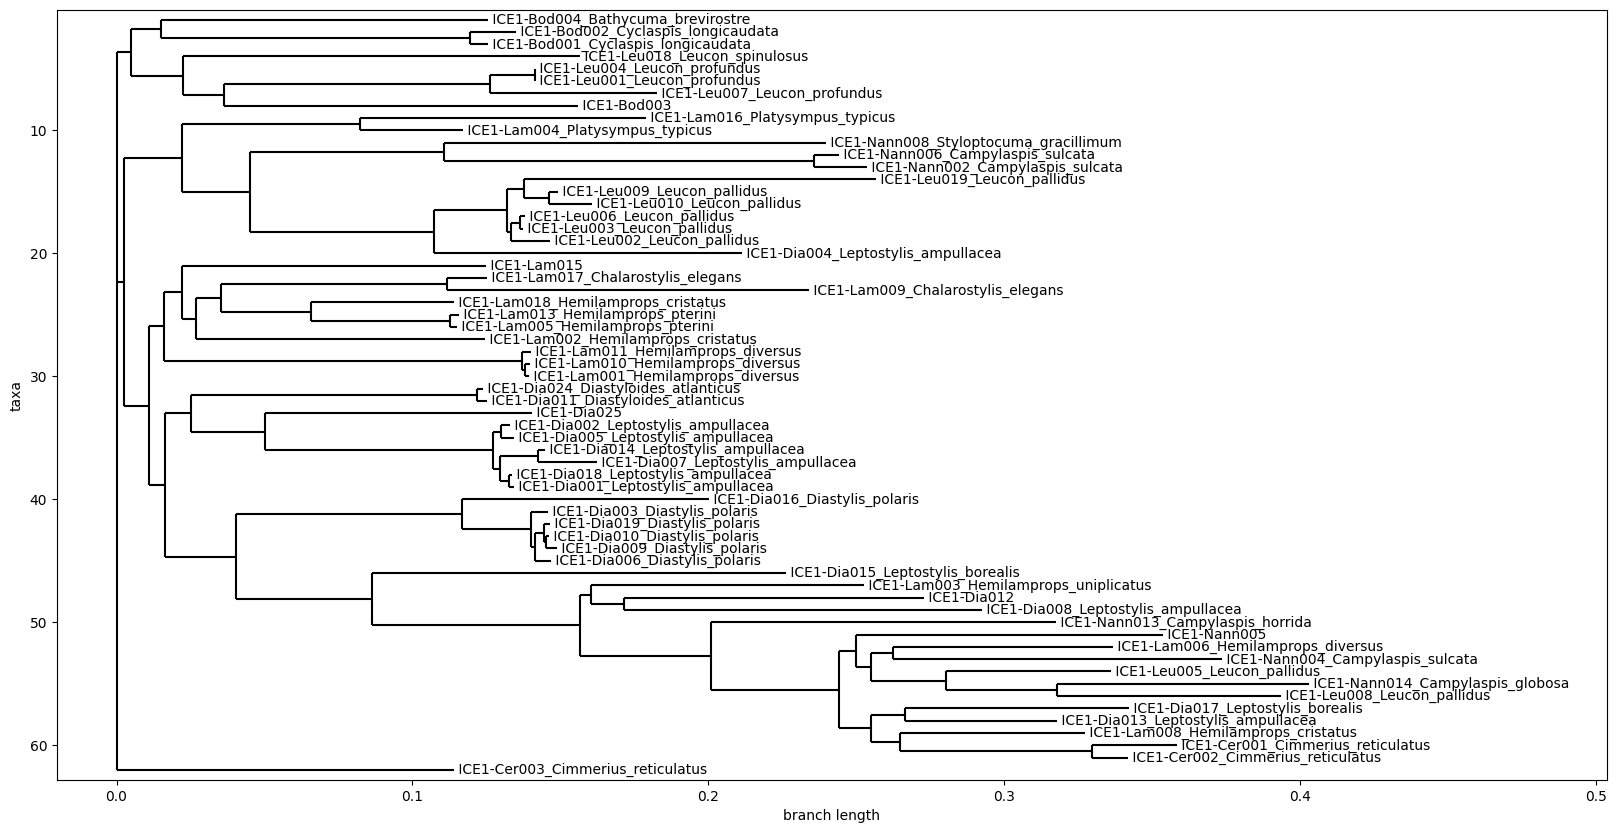

In [51]:
build_tree(
    r"C:\Users\adm1\Downloads\Final_sequences_aligned_MAFFT_Ubuntu_CIAlign_cleaned_1_tree.fasta"
)

In [11]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv(r"../data/Dataset_Tree_ID_3.csv")

# Create a new column 'geolocation' combining 'longitude' and 'latitude' as a tuple
df["geolocation"] = list(zip(df["longitude"], df["latitude"]))

# Create a mapping of unique geolocation points to unique integer IDs
geolocation_mapping = {
    geo: idx + 1 for idx, geo in enumerate(df["geolocation"].unique())
}

# Update the 'caffeine_percent' column with the unique integer ID for each geolocation
df["caffeine_percent"] = df["geolocation"].map(geolocation_mapping)

# Optionally drop the 'geolocation' column as it's no longer needed
df.drop(columns=["geolocation"], inplace=True)

# Check the updated DataFrame
print(df)

# Save the updated DataFrame back to a CSV (optional)
df.to_csv(r"../data/Updated_Dataset_Tree_ID_3.csv", index=False)

                           specimen_id  longitude  latitude  caffeine_percent
0   ICE1-Bod001_Cyclaspis_longicaudata    -18.136    60.046                 1
1                          ICE1-Bod003    -28.068    63.018                 2
2    ICE1-Bod004_Bathycuma_brevirostre    -18.136    60.046                 1
3    ICE1-Cer002_Cimmerius_reticulatus    -28.068    63.018                 2
4    ICE1-Cer003_Cimmerius_reticulatus    -28.068    63.018                 2
..                                 ...        ...       ...               ...
57        ICE1-Leu001_Leucon_profundus    -26.767    67.633                 4
58        ICE1-Leu004_Leucon_profundus    -26.767    67.633                 4
59         ICE1-Leu005_Leucon_pallidus    -26.767    67.633                 4
60         ICE1-Leu009_Leucon_pallidus    -23.696    67.860                 6
61                        ICE1-Nann005    -28.068    63.018                 2

[62 rows x 4 columns]


In [42]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from Bio import Phylo
import argparse


def custom_label(clade):
    if clade.is_terminal():
        return clade.name
    else:
        return None


def calc_node_positions(tree, x_start, x_end, y_start, y_step):
    if tree.is_terminal():
        x_pos = x_start
        y_pos = y_start
        y_start += y_step
    else:
        x_pos = (x_start + x_end) / 2
        y_pos = y_start

        child_y_start = y_start
        for child in tree.clades:
            child_x_pos, child_y_pos, y_start = calc_node_positions(
                child, x_start, x_end, y_start, y_step
            )
            x_start = child_x_pos

        y_pos = (y_start + child_y_start) / 2

    tree.position = (x_pos, y_pos)
    return x_pos, y_pos, y_start


def get_x_offset(node_name, offsets_dict):
    return offsets_dict.get(node_name, 0)  # default offset is 0 if not found


def plot_adjusted_node(ax, node, y_offset, offsets_dict, gps):
    x, y = node.position
    x_offset = get_x_offset(node.name, offsets_dict)
    x += x_offset
    y += y_offset

    # Default color if node name is not found
    color = "grey"

    # Check if node name is in the gps DataFrame and set color accordingly
    if node.name in gps["specimen_id"].values:
        color = gps[gps["specimen_id"] == node.name]["color"].values[0]

    ax.plot(
        x,
        y,
        "o",
        markersize=8,
        markerfacecolor=color,
        markeredgewidth=2,
        markeredgecolor="black",
    )
    return x, y


# Step 1: Group geolocations by unique coordinates and assign colors
def assign_colors_by_geolocation(gps):
    gps["geo_group"] = gps.groupby(["longitude", "latitude"]).ngroup()
    colormap = plt.get_cmap(
        "tab20", gps["geo_group"].nunique()
    )  # Generate distinct colors
    geo_color_map = dict(
        zip(gps["geo_group"], [mcolors.to_hex(colormap(i)) for i in range(colormap.N)])
    )
    gps["color"] = gps["geo_group"].apply(
        lambda group: geo_color_map.get(group, "grey")
    )
    return gps


# Main code
fig = plt.figure(figsize=(26, 11))

# Load the tree
nwk_file = r"..\data\Final_sequences_aligned_MAFFT_Ubuntu_CIAlign_cleaned_1_tree.nwk"
tree = Phylo.read(nwk_file, "newick")

# Load offsets from CSV
offset_file = r"..\data\offset0.csv"
offsets_df = pd.read_csv(offset_file)
offsets_dict = pd.Series(offsets_df.XOffset.values, index=offsets_df.NodeName).to_dict()

# Calculate positions for all nodes
y_step = 1
calc_node_positions(tree.root, 0, 1, 0, y_step)

# Create a subplot for the phylogenetic tree
ax_tree = fig.add_subplot(121)

# Load GPS data
gps_file = r"..\data\Dataset_Tree_ID_2.csv"
gps = pd.read_csv(gps_file)
gps = assign_colors_by_geolocation(gps)  # Assign consistent colors by geolocation

# Plot the tree
Phylo.draw(tree, do_show=False, axes=ax_tree, label_func=custom_label)
ax_tree.set_frame_on(False)  # Remove the border/frame

# Set axes limits
ax_tree.set_xlim(-0.02, 1)
ax_tree.set_ylim(0, max(node.position[1] for node in tree.get_terminals()) + 2)

# Store node positions
node_positions = {clade.name: clade.position for clade in tree.find_clades()}

# Plot the nodes with adjusted colors and positions
for clade in tree.find_clades():
    if clade.is_terminal():
        plot_adjusted_node(ax_tree, clade, y_step, offsets_dict, gps)

# Create a subplot for the map
ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
extent = [-32, -10, 55, 69]
ax2.set_extent(extent)

# Plot GPS points on the map
for index, row in gps.iterrows():
    ax2.plot(
        row["longitude"],
        row["latitude"],
        "o",
        markersize=8,
        markerfacecolor=row["color"],
        markeredgewidth=2,
        markeredgecolor="black",
    )

# Add features for context
ax2.coastlines(resolution="10m")
ax2.add_feature(cfeature.LAND)
ax2.add_feature(cfeature.OCEAN)
ax2.add_feature(cfeature.COASTLINE)
ax2.add_feature(cfeature.BORDERS)

ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")

# Create connections between tree nodes and geolocations
gps_grouped = (
    gps.groupby("specimen_id")[["longitude", "latitude", "color"]]
    .apply(lambda x: list(zip(x["longitude"], x["latitude"], x["color"])))
    .to_dict()
)

for clade in tree.find_clades():
    if clade.name in gps_grouped:
        for longitude, latitude, color in gps_grouped[clade.name]:
            con = ConnectionPatch(
                xyA=node_positions[clade.name],
                coordsA="data",
                xyB=(longitude, latitude),
                coordsB="data",
                axesA=ax_tree,
                axesB=ax2,
                color=color,
                linewidth=1,
                linestyle="--",
                alpha=0.5,
                zorder=2,
            )
            fig.add_artist(con)

plt.tight_layout()

# Save the output
output_file = r"..\images\figure_tree2map.png"
plt.savefig(output_file, format="png")
plt.close(fig)